# EDA - Data from 2022 to 2025 

Objective of the notebook: Upload the four files corresponding to the four yeears 2022-2025, clean and explore them. And investigate how significant wave height (WVHT) varies with meteorological and oceanographic conditions measured by buoy 41001, and identify variables that may be useful for a regression model.

# loading the data and the libraries:

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [53]:
cols=["YY","MM","DD","hh","mm","WDIR","WSPD","GST","WVHT",
        "DPD","APD","MWD","PRES","ATMP","WTMP","DEWP","VIS","TIDE"]
data2022=pd.read_csv("../data/raw/41001h2022.txt",sep=r'\s+', skiprows=2, names=cols)
data2023=pd.read_csv("../data/raw/41001h2023.txt",sep=r'\s+', skiprows=2, names=cols)
data2024=pd.read_csv("../data/raw/41001h2024.txt",sep=r'\s+', skiprows=2, names=cols)
data2025=pd.read_csv("../data/raw/41001h2025.txt",sep=r'\s+', skiprows=2, names=cols)



In [54]:
data_files={
    "2022data":data2022,
    "2023data":data2023,
    "2024data":data2024,
    "2025data":data2025,
}

# Exploring the data

In [55]:
for name, df in data_files.items():
    print(f"\n{name}")
    print(df.shape)
    print(df.info())


2022data
(43766, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43766 entries, 0 to 43765
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   YY      43766 non-null  int64  
 1   MM      43766 non-null  int64  
 2   DD      43766 non-null  int64  
 3   hh      43766 non-null  int64  
 4   mm      43766 non-null  int64  
 5   WDIR    43766 non-null  int64  
 6   WSPD    43766 non-null  float64
 7   GST     43766 non-null  float64
 8   WVHT    43766 non-null  float64
 9   DPD     43766 non-null  float64
 10  APD     43766 non-null  float64
 11  MWD     43766 non-null  int64  
 12  PRES    43766 non-null  float64
 13  ATMP    43766 non-null  float64
 14  WTMP    43766 non-null  float64
 15  DEWP    43766 non-null  float64
 16  VIS     43766 non-null  float64
 17  TIDE    43766 non-null  float64
dtypes: float64(11), int64(7)
memory usage: 6.0 MB
None

2023data
(50450, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5

In [56]:
for name, df in data_files.items():
    print(f"\n{name}")
    print(df.isnull().sum())


2022data
YY      0
MM      0
DD      0
hh      0
mm      0
WDIR    0
WSPD    0
GST     0
WVHT    0
DPD     0
APD     0
MWD     0
PRES    0
ATMP    0
WTMP    0
DEWP    0
VIS     0
TIDE    0
dtype: int64

2023data
YY      0
MM      0
DD      0
hh      0
mm      0
WDIR    0
WSPD    0
GST     0
WVHT    0
DPD     0
APD     0
MWD     0
PRES    0
ATMP    0
WTMP    0
DEWP    0
VIS     0
TIDE    0
dtype: int64

2024data
YY      0
MM      0
DD      0
hh      0
mm      0
WDIR    0
WSPD    0
GST     0
WVHT    0
DPD     0
APD     0
MWD     0
PRES    0
ATMP    0
WTMP    0
DEWP    0
VIS     0
TIDE    0
dtype: int64

2025data
YY      0
MM      0
DD      0
hh      0
mm      0
WDIR    0
WSPD    0
GST     0
WVHT    0
DPD     0
APD     0
MWD     0
PRES    0
ATMP    0
WTMP    0
DEWP    0
VIS     0
TIDE    0
dtype: int64


In [57]:
col =['YY', 'MM', 'DD', 'hh', 'mm', 'WDIR', 'WSPD', 'GST', 'WVHT', 'DPD',
      'APD', 'MWD', 'PRES', 'ATMP', 'WTMP', 'DEWP', 'VIS', 'TIDE']
for name,df in data_files.items():
      print(name)
      print((df[col] == 99.00).sum())

2022data
YY          0
MM          0
DD          0
hh          0
mm          0
WDIR       85
WSPD       16
GST        16
WVHT    35791
DPD     35791
APD     35791
MWD        28
PRES        0
ATMP        0
WTMP        0
DEWP        0
VIS     43766
TIDE    43766
dtype: int64
2023data
YY          0
MM          0
DD          0
hh          0
mm          0
WDIR       49
WSPD       22
GST        24
WVHT    33691
DPD     33691
APD     33691
MWD        57
PRES        0
ATMP        0
WTMP        0
DEWP        0
VIS     50450
TIDE    50450
dtype: int64
2024data
YY          0
MM          0
DD          0
hh          0
mm          0
WDIR       40
WSPD       10
GST        10
WVHT    15218
DPD     15218
APD     15218
MWD        28
PRES        0
ATMP        0
WTMP        0
DEWP        0
VIS     22802
TIDE    22802
dtype: int64
2025data
YY          0
MM          0
DD          0
hh          0
mm          0
WDIR       82
WSPD       19
GST        19
WVHT    15953
DPD     15953
APD     15953
MWD        39
P

In [58]:
for name, df in data_files.items():
    print(df.duplicated().sum())


0
0
0
0


# Cleaning

In [59]:
clean_data_files={}
for name, df in data_files.items():
    df=df.copy()
    df=df.drop(["MWD","ATMP","WTMP","DEWP","VIS","TIDE","APD","DPD"], axis=1)
    clean_data_files[name] = df

In [60]:
for name,df in clean_data_files.items():
    df.rename(columns=
    {
    "YY":"Y",
    "MM":"M",
    "DD":"D",
    "hh":"h",
    "mm":"m",
    "WSPD":"Wind speed",
    "GST":"Wind gust",
    "WVHT":"Significant wave height",
    "PRES":"Atmospheric pressure",
    "WDIR":"wind direction",
    }
    ,inplace=True)

In [61]:
for name,df in clean_data_files.items():
    print(name)
    print(df.columns)

2022data
Index(['Y', 'M', 'D', 'h', 'm', 'wind direction', 'Wind speed', 'Wind gust',
       'Significant wave height', 'Atmospheric pressure'],
      dtype='object')
2023data
Index(['Y', 'M', 'D', 'h', 'm', 'wind direction', 'Wind speed', 'Wind gust',
       'Significant wave height', 'Atmospheric pressure'],
      dtype='object')
2024data
Index(['Y', 'M', 'D', 'h', 'm', 'wind direction', 'Wind speed', 'Wind gust',
       'Significant wave height', 'Atmospheric pressure'],
      dtype='object')
2025data
Index(['Y', 'M', 'D', 'h', 'm', 'wind direction', 'Wind speed', 'Wind gust',
       'Significant wave height', 'Atmospheric pressure'],
      dtype='object')


In [62]:
for name, df in clean_data_files.items():
    clean_data_files[name] = df[df["Significant wave height"] != 99.00]

In [63]:
for name, df in clean_data_files.items():
    clean_data_files[name] = df[df["wind direction"] != 999]

In [64]:
for name, df in clean_data_files.items():
    clean_data_files[name] = df[df["Significant wave height"] <= 20]

In [65]:
for name,df in clean_data_files.items():
    print(name)
    print(df["Significant wave height"].max())

2022data
8.2
2023data
6.85
2024data
4.59
2025data
12.06


In [66]:
for name, df in clean_data_files.items():
    df['time'] = pd.to_datetime(
        df[['Y','M','D','h','m']].rename(
            columns={'Y':'year','M':'month','D':'day','h':'hour','m':'minute'}
        )
    )
    clean_data_files[name] = df

In [67]:
for name, df in clean_data_files.items():
    clean_data_files[name] = df.set_index('time')

In [68]:
for name, df in clean_data_files.items():
    print(name)
    print(df.head())

2022data
                        Y  M  D   h   m  wind direction  Wind speed  \
time                                                                  
2022-03-02 20:40:00  2022  3  2  20  40             234         8.3   
2022-03-02 21:40:00  2022  3  2  21  40             236         9.3   
2022-03-02 22:40:00  2022  3  2  22  40             235         7.7   
2022-03-02 23:40:00  2022  3  2  23  40             230         7.3   
2022-03-03 00:40:00  2022  3  3   0  40             209         4.9   

                     Wind gust  Significant wave height  Atmospheric pressure  
time                                                                           
2022-03-02 20:40:00       10.8                     1.31                1017.5  
2022-03-02 21:40:00       11.5                     1.46                1017.7  
2022-03-02 22:40:00        9.6                     1.63                1018.0  
2022-03-02 23:40:00       10.7                     1.40                1018.3  
2022-03-03 00

In [69]:
for name, df in clean_data_files.items():
    theta = np.radians(df["wind direction"])
    df["wind_dir_x"] = np.cos(theta)
    df["wind_dir_y"] = np.sin(theta)

2022data


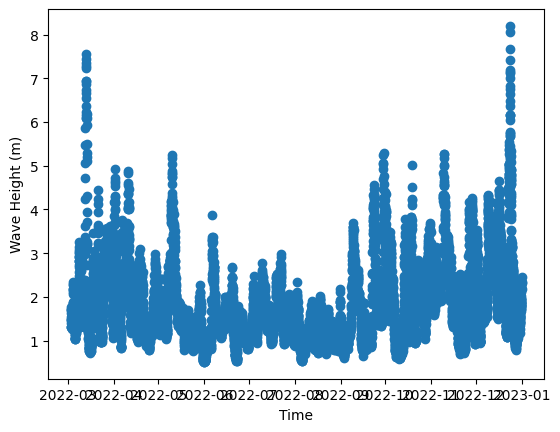

2023data


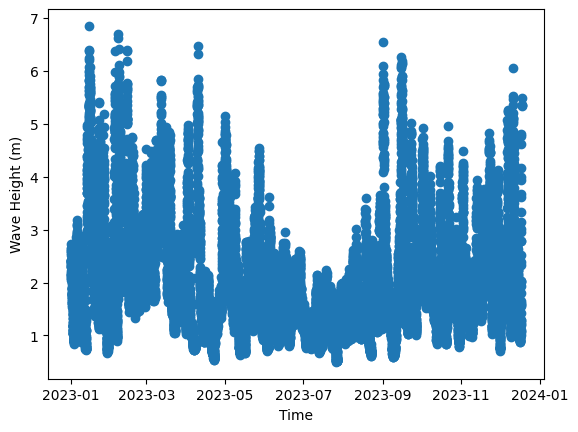

2024data


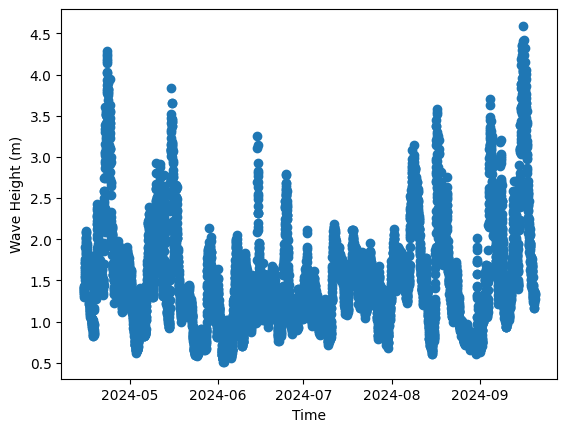

2025data


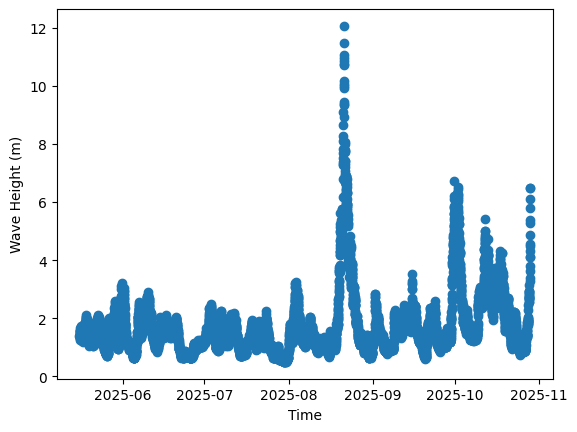

In [70]:
for name, df in clean_data_files.items():
    print(name)
    plt.scatter(df.index, df['Significant wave height'])
    plt.xlabel("Time")
    plt.ylabel("Wave Height (m)")
    plt.show()

# Merging the four years data in one csv

In [71]:
data = pd.concat(clean_data_files.values())
data['time'] = pd.to_datetime(
    data[['Y','M','D','h','m']].rename(
        columns={'Y':'year','M':'month','D':'day','h':'hour','m':'minute'}
    )
)
data = data.set_index('time')
data = data.sort_index()

In [73]:
data.to_csv("../data/clean/cleandata.csv", index=True)

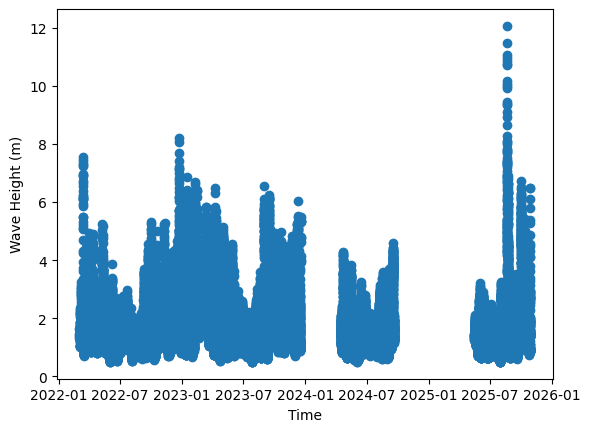

In [74]:
plt.scatter(data.index, data['Significant wave height'])
plt.xlabel("Time")
plt.ylabel("Wave Height (m)")
plt.show()